# Healthcare Readmission & Hospital Performance Analysis

## Project Overview

Hospital readmissions are an important performance indicator in the healthcare industry. High readmission rates can increase treatment costs, reduce operational efficiency, and may indicate opportunities to improve patient care.

In this project, I performed an end-to-end exploratory data analysis (EDA) on a healthcare dataset to identify patterns in patient readmissions and evaluate hospital performance. The analysis focuses on cleaning the data, exploring patient and hospital characteristics, calculating key healthcare KPIs, and generating business insights to support data-driven decision-making.

---

## Business Objectives

- Analyze patient readmission patterns.
- Evaluate hospital and department performance.
- Identify factors associated with higher readmission rates.
- Calculate key healthcare KPIs.
- Provide actionable business recommendations based on the analysis.

---

## Dataset Overview

The dataset contains patient-level healthcare records, including demographic information, hospital admissions, medical conditions, treatment details, and readmission status. These attributes are analyzed to understand trends that influence hospital performance and patient outcomes.

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## Skills Demonstrated

- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Data Visualization
- KPI Analysis
- Business Insights
- Business Recommendations

---
---

## Importing Required Libraries

This section imports the libraries required for data manipulation, visualization, and notebook configuration. These libraries will be used throughout the project for data cleaning, exploratory data analysis (EDA), and business reporting.

In [19]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utility
import warnings

# Notebook settings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 70)
print("Healthcare Readmission & Hospital Performance Analysis")
print("=" * 70)
print("Libraries imported successfully.")

Healthcare Readmission & Hospital Performance Analysis
Libraries imported successfully.


### Summary

- All required libraries were successfully imported.
- Display settings were configured to improve data exploration.
- Visualization styles were standardized for consistent charts throughout the analysis.

---
---

# Loading the Dataset

The first step in any data analysis project is loading the dataset and performing a quick inspection. This helps verify that the data has been imported correctly and provides an initial understanding of its structure, columns, and overall contents before data cleaning begins.

In [20]:
# ==========================================================
# Load Dataset
# ==========================================================

# Load the healthcare dataset
df = pd.read_csv("diabetes_data.csv")

# Display the first five rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Initial Dataset Exploration

Before cleaning the data, it is important to understand the dataset's size, structure, data types, and summary statistics. This initial exploration helps identify potential data quality issues such as missing values, incorrect data types, and unusual values.

In [21]:
# Dataset dimensions
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# Dataset information
df.info()

# Summary statistics for numerical columns
display(df.describe())

# Summary statistics for categorical columns
display(df.describe(include="object"))

Number of Rows: 101766
Number of Columns: 50
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-nul

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,17018,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,3,4,4,4,4,4,2,4,4,2,4,4,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,8216,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,95401,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


### Key Findings

- The dataset contains **101,766 patient records** and **50 variables**, providing a large sample for healthcare analysis.
- It consists of **13 numerical columns** and **37 categorical columns**, allowing analysis of patient demographics, hospital visits, diagnoses, medications, and readmission status.
- Several columns, such as **`max_glu_serum`** and **`A1Cresult`**, contain a high number of missing values and will require further investigation during the data cleaning phase.
- The dataset includes the **`readmitted`** column, which will be the primary variable used to analyze patient readmission patterns throughout this project.
- Overall, the dataset has been loaded successfully and is ready for data cleaning and preprocessing.

---
---

# Data Quality Assessment

Before performing any analysis, it is important to assess the quality of the dataset. This involves checking for duplicate records, identifying missing values, detecting placeholder values, and reviewing data types. Understanding these issues helps ensure that the data is properly cleaned before further analysis.

In [22]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

# ==========================================================
# Missing Values
# ==========================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().sum() / len(df) * 100, 2)
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

print("Missing Values Summary")
display(missing_values.sort_values("Missing Values", ascending=False))

# ==========================================================
# Placeholder Values
# ==========================================================

placeholder_count = (df == "?").sum()

placeholder_summary = pd.DataFrame({
    "Placeholder Count": placeholder_count,
    "Percentage (%)": round(placeholder_count / len(df) * 100, 2)
})

placeholder_summary = placeholder_summary[
    placeholder_summary["Placeholder Count"] > 0
]

print("Placeholder ('?') Summary")
display(placeholder_summary.sort_values("Placeholder Count", ascending=False))

# ==========================================================
# Check total unique patients vs total visits
# ==========================================================
total_visits = df['encounter_id'].nunique()
total_patients = df['patient_nbr'].nunique()

print(f"Total Hospital Visits: {total_visits}")
print(f"Total Unique Patients: {total_patients}")

Duplicate Records: 0
Missing Values Summary


,Missing Values,Percentage (%)
max_glu_serum,96420,94.75
A1Cresult,84748,83.28


Placeholder ('?') Summary


,Placeholder Count,Percentage (%)
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Total Hospital Visits: 101766
Total Unique Patients: 71518


## Key Findings

- No duplicate records were found in the dataset.
- Pandas did not initially detect any missing values because missing information is stored as the placeholder `"?"` rather than actual `NaN` values.
- Several columns, including **Weight**, **Payer Code**, **Medical Specialty**, **Max Glucose Serum**, and **A1C Result**, contain a large number of placeholder values.
- The identified data quality issues will be addressed in the next section during data cleaning and preprocessing.

---
---

# Data Cleaning & Preprocessing

After assessing the dataset, the next step is to clean and prepare it for analysis. This includes handling missing values, removing unnecessary columns, and creating a consistent dataset for exploratory data analysis (EDA). Proper data cleaning improves the accuracy and reliability of business insights.

In [23]:
# ==========================================================
# Data Cleaning & Preprocessing
# ==========================================================

# Replace placeholder values with missing values
df.replace("?", np.nan, inplace=True)

# Remove columns that are not useful for analysis
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df.drop(columns=columns_to_drop, inplace=True)

# Replace missing values in test columns with 'Not Tested'
df['A1Cresult'] = df['A1Cresult'].fillna('Not Tested')
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Tested')

# Fill missing values in important categorical columns
categorical_columns = [
    "race",
    "gender",
    "diag_1",
    "diag_2",
    "diag_3"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Convert age ranges to midpoint values
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age_numeric"] = df["age"].map(age_mapping)

# Verify cleaned dataset
print(f"Dataset Shape: {df.shape}")

display(df.head())

# ==========================================================
# Replace Admission IDs with Descriptive Labels
# ==========================================================

# Admission Type
admission_type = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "Unknown",
    7: "Trauma Center",
    8: "Not Mapped"
}

# Admission Source
admission_source = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from Hospital",
    5: "Transfer from Skilled Nursing Facility",
    6: "Transfer from Other Healthcare Facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Unknown",
    10: "Transfer from Critical Access Hospital",
    11: "Normal Delivery",
    14: "Extramural Birth",
    18: "Transfer from Hospice"
}

# Discharge Disposition
discharge_disposition = {
    1: "Discharged Home",
    2: "Transferred to Short-term Hospital",
    3: "Transferred to Skilled Nursing Facility",
    4: "Transferred to Intermediate Care",
    5: "Transferred to Another Facility",
    6: "Home with Home Health Service",
    7: "Left Against Medical Advice",
    8: "Home IV Provider",
    11: "Expired",
    13: "Hospice Home",
    14: "Hospice Medical Facility",
    18: "Transferred to Rehab Facility",
    22: "Transferred to Psychiatric Hospital",
    23: "Transferred to Long-term Care Hospital",
    24: "Transferred to Nursing Facility",
    25: "Not Mapped",
    28: "Another Institution",
    41: "Expired at Home"
}

df["admission_type"] = df["admission_type_id"].map(admission_type).fillna("Other")

df["admission_source"] = df["admission_source_id"].map(admission_source).fillna("Other")

df["discharge_disposition"] = df["discharge_disposition_id"].map(discharge_disposition).fillna("Other")


Dataset Shape: (101766, 48)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,age_numeric
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,5
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,15
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,Not Tested,Not Tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,25
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,35
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,Not Tested,Not Tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,45


### Summary

Before performing analysis, the dataset was cleaned to improve data quality and ensure reliable results.

The following preprocessing steps were performed:

- Replaced placeholder values (`?`) with missing values (`NaN`).
- Removed columns with a very high percentage of missing values (`weight`, `payer_code`, `medical_specialty`).
- Replaced missing lab results with `Not Tested` to represent unconducted tests rather than data entry errors.
- Filled missing values in selected categorical columns with **"Unknown"** where appropriate.
- Replaced coded admission, admission source, and discharge IDs with descriptive labels to improve readability.

The cleaned dataset is now ready for exploratory data analysis.

---
---

# Cleaned Dataset Summary

After completing the data cleaning process, this section provides a final overview of the cleaned dataset. It confirms that the data is ready for exploratory data analysis by summarizing the dataset structure and checking for any remaining missing values.

In [24]:
# ==========================================================
# Cleaned Dataset Summary
# ==========================================================

# Number of numerical and categorical columns
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

print(f"Dataset Shape: {df.shape}")
print(f"Numerical Columns: {len(numeric_columns)}")
print(f"Categorical Columns: {len(categorical_columns)}")

# Remaining missing values
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

if missing_summary.empty:
    print("\nNo missing values remain in the dataset.")
else:
    display(missing_summary.sort_values("Percentage", ascending=False))

Dataset Shape: (101766, 51)
Numerical Columns: 14
Categorical Columns: 37

No missing values remain in the dataset.


# Exploratory Data Analysis (EDA)

The objective of Exploratory Data Analysis (EDA) is to understand patient characteristics, hospital utilization, and readmission patterns through visualizations and summary statistics. The insights obtained from this analysis help identify important trends that can support healthcare decision-making and improve hospital performance.

The analysis is divided into business-focused sections rather than chart types, making it easier to interpret the results and communicate findings.

---
---

# Readmission Overview

## Purpose

Hospital readmission is a key performance indicator (KPI) that reflects the quality of patient care and hospital performance. This section provides an overview of patient readmission patterns by analyzing the distribution of readmission outcomes.

Understanding these patterns helps establish a baseline for the remaining analysis and identifies the proportion of patients who were readmitted within or after 30 days following discharge.

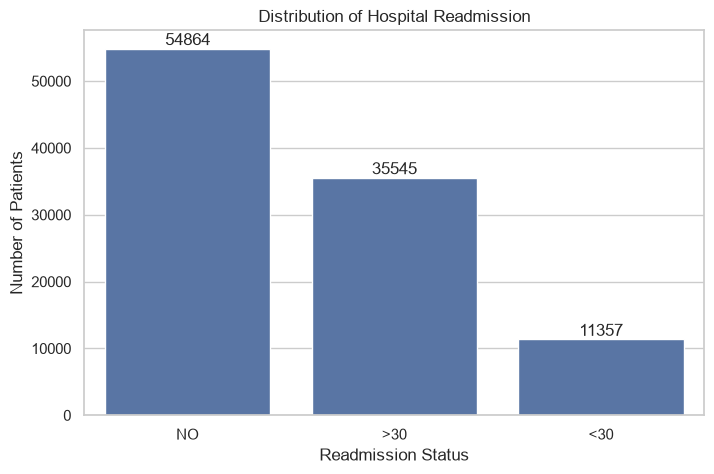

In [25]:
plt.figure(figsize=(8,5))

ax= sns.countplot(
    data=df,
    x="readmitted",
    order=["NO", ">30", "<30"]
)

plt.title("Distribution of Hospital Readmission")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

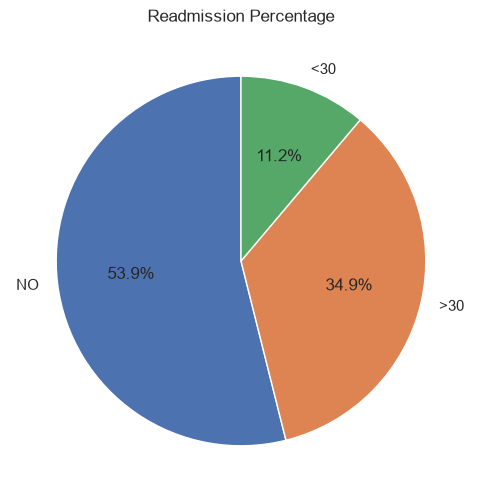

In [26]:
plt.figure(figsize=(6,6))
readmission_counts = df['readmitted'].value_counts()

plt.pie(
    readmission_counts,
    labels=readmission_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Readmission Percentage")

plt.show()

### Key Findings

- Approximately **54%** of hospital admissions did not result in a readmission.
- Around **35%** of patients were readmitted after 30 days.
- Only about **11%** of patients were readmitted within 30 days.
- The relatively low proportion of early readmissions suggests that most patients did not require immediate rehospitalization after discharge.

---

### Business Insight

Although most patients were not readmitted, nearly half experienced a return visit at some point. Monitoring patients with higher readmission risk and strengthening post-discharge follow-up may help improve patient outcomes and reduce avoidable hospital utilization.

---
---

# Patient Demographics

## Purpose

Patient demographics play an important role in understanding hospital readmission patterns. This section explores the distribution of patients by age, gender, and race to identify the characteristics of the hospital population.

Understanding the demographic profile provides valuable context for interpreting readmission trends and supports more targeted healthcare decision-making.

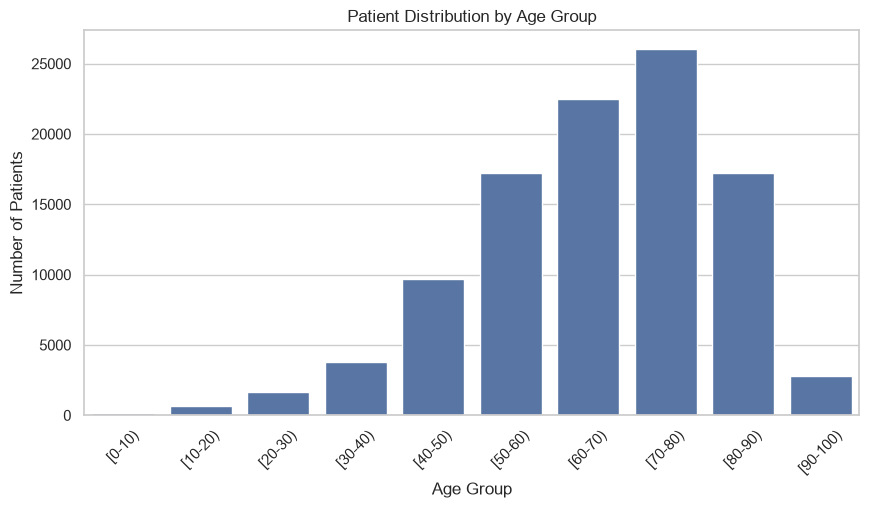

In [27]:
# ==========================================================
# Age Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="age",
    order=sorted(df["age"].unique())
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

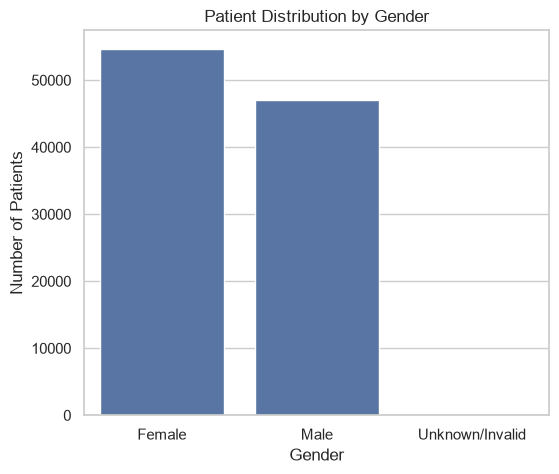

In [28]:
# ==========================================================
# Gender Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

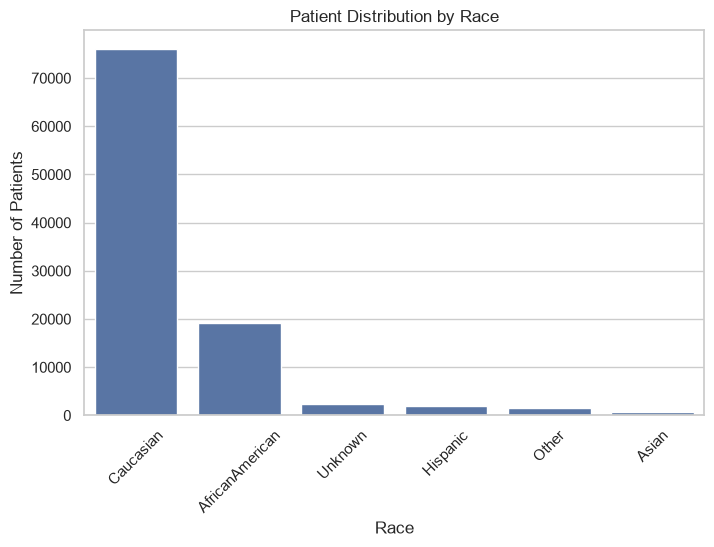

In [29]:
# ==========================================================
# Race Distribution
# ==========================================================

plt.figure(figsize=(8,5))

race_counts = df["race"].value_counts()

sns.barplot(
    x=race_counts.index,
    y=race_counts.values
)

plt.title("Patient Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

### Key Findings

- The majority of patients were between **60 and 80 years** of age.
- Female patients represented a slightly larger proportion of hospital admissions than male patients.
- Most admissions involved Caucasian patients, while other racial groups accounted for a smaller share of the dataset.
- The patient population was largely composed of older adults, indicating a higher burden of diabetes-related hospitalizations in this age group.

---

### Business Insight

Understanding the demographic profile of admitted patients helps healthcare providers design targeted care strategies. Since older adults account for most admissions, preventive care and follow-up programs focused on this population may improve healthcare outcomes.

---
---                                                                                                                                                 

# Hospital & Treatment Analysis

## Purpose

This section examines key hospital and treatment metrics to understand patient care during hospitalization. The analysis focuses on hospital stay duration, number of diagnoses, medications prescribed, and laboratory procedures performed.

These metrics provide an overview of healthcare resource utilization and treatment intensity.

Average Hospital Stay     : 4.4 days
Average Diagnoses         : 7.4
Average Medications       : 16.0
Average Lab Procedures    : 43.1


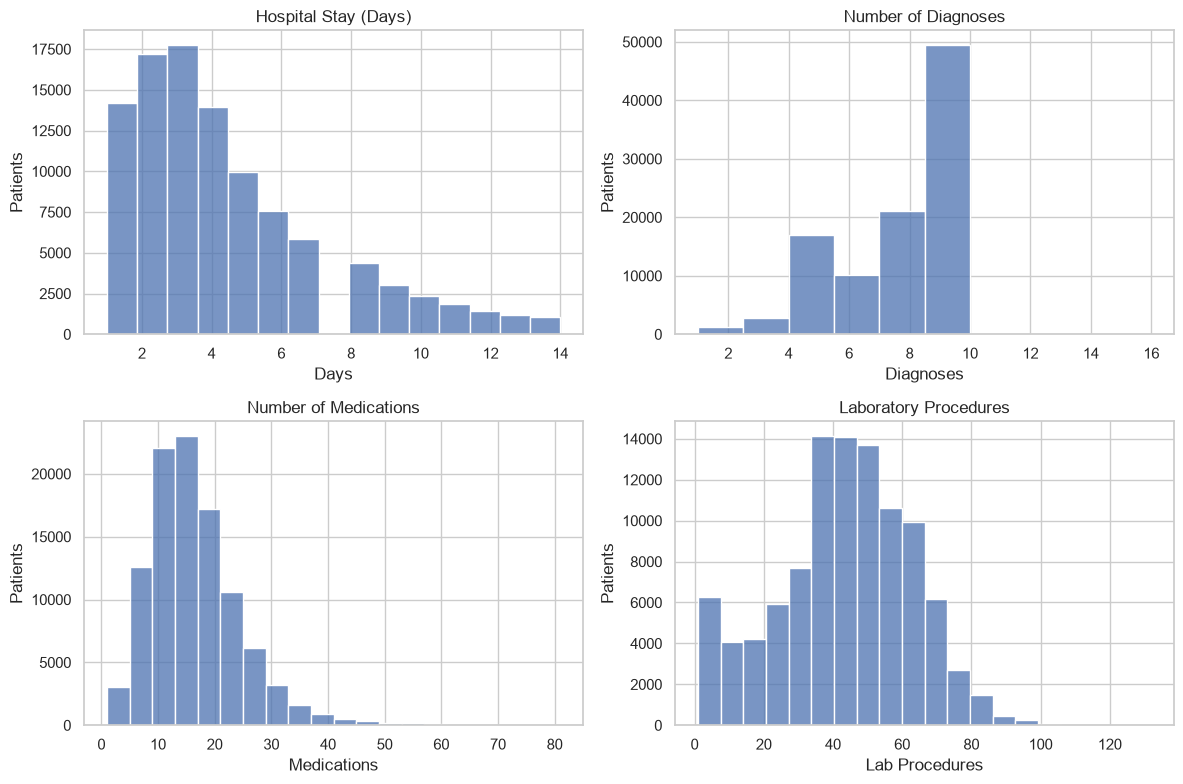

In [30]:
print(f"Average Hospital Stay     : {df['time_in_hospital'].mean():.1f} days")
print(f"Average Diagnoses         : {df['number_diagnoses'].mean():.1f}")
print(f"Average Medications       : {df['num_medications'].mean():.1f}")
print(f"Average Lab Procedures    : {df['num_lab_procedures'].mean():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Hospital Stay
sns.histplot(data=df, x="time_in_hospital", bins=15, ax=axes[0,0])
axes[0,0].set_title("Hospital Stay (Days)")
axes[0,0].set_xlabel("Days")
axes[0,0].set_ylabel("Patients")

# Number of Diagnoses
sns.histplot(data=df, x="number_diagnoses", bins=10, ax=axes[0,1])
axes[0,1].set_title("Number of Diagnoses")
axes[0,1].set_xlabel("Diagnoses")
axes[0,1].set_ylabel("Patients")

# Number of Medications
sns.histplot(data=df, x="num_medications", bins=20, ax=axes[1,0])
axes[1,0].set_title("Number of Medications")
axes[1,0].set_xlabel("Medications")
axes[1,0].set_ylabel("Patients")

# Number of Lab Procedures
sns.histplot(data=df, x="num_lab_procedures", bins=20, ax=axes[1,1])
axes[1,1].set_title("Laboratory Procedures")
axes[1,1].set_xlabel("Lab Procedures")
axes[1,1].set_ylabel("Patients")

plt.tight_layout()

plt.show()

### Key Findings

- Most hospital stays lasted between **2 and 6 days**, indicating relatively short admissions.
- Patients typically received multiple medications and laboratory procedures during hospitalization.
- The number of diagnoses varied across patients, reflecting differences in medical complexity.
- Hospital resource utilization increased with patient complexity and treatment requirements.

---

### Business Insight

Hospital stay duration, laboratory procedures, medications, and diagnoses provide useful indicators of healthcare resource utilization. Tracking these measures can support workload planning, staffing decisions, and efficient allocation of hospital resources.

---
---
    

# Admission & Medication Analysis

## Purpose

This section examines how patients were admitted to the hospital and explores medication-related information during hospitalization.
Understanding admission methods and medication usage helps provide insights into hospital operations and patient treatment practices.

Unique Admission Types      : 8
Unique Admission Sources    : 13
Patients Receiving Diabetes Medication : 78,363
Medication Changed During Stay : 47,011


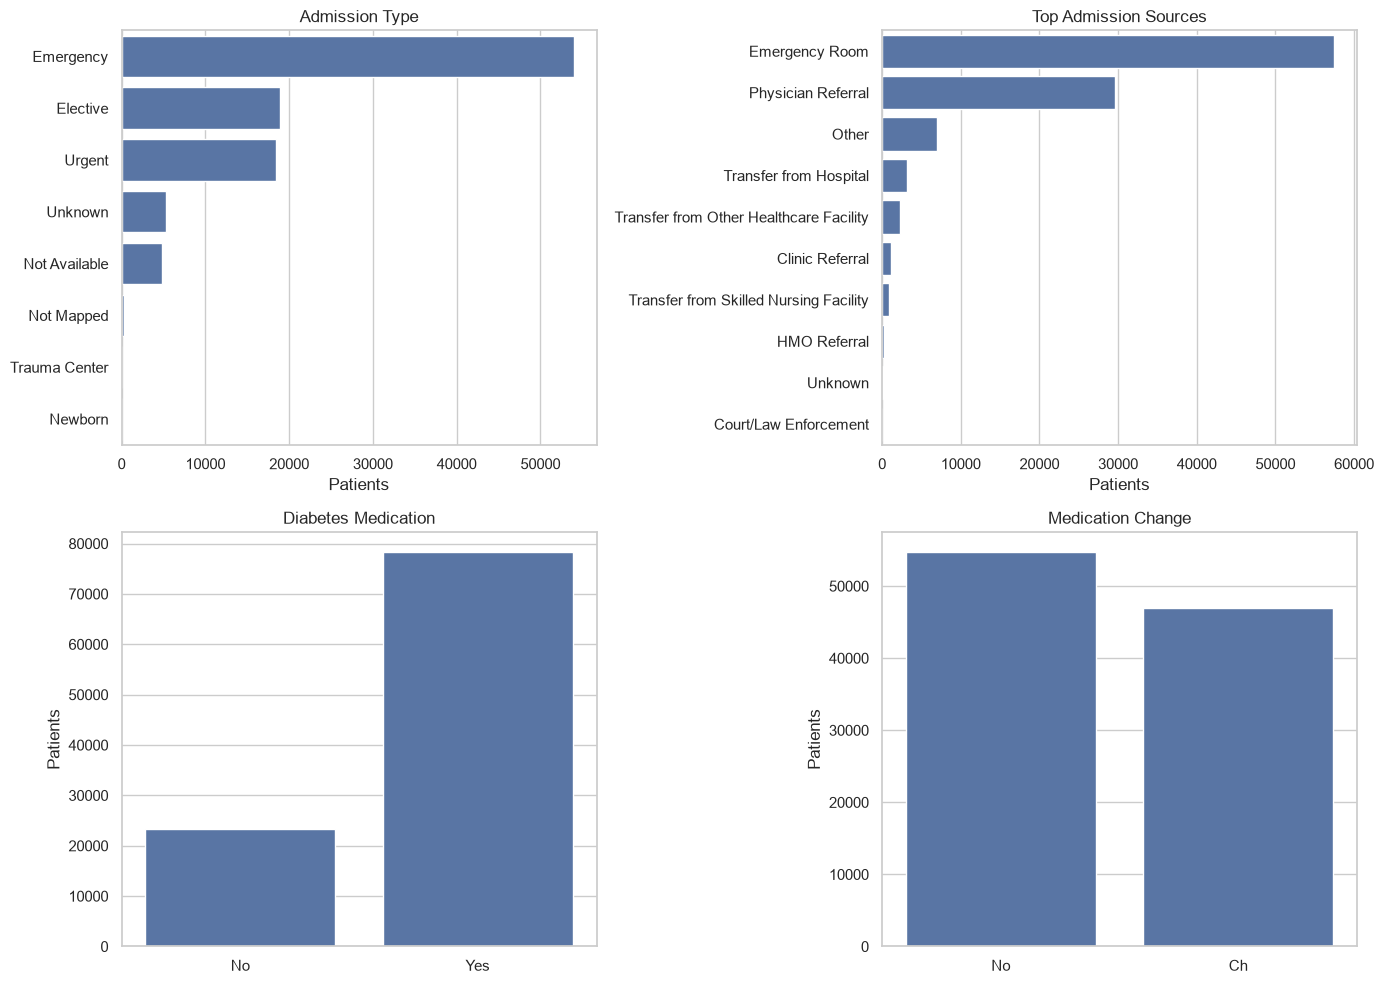

In [31]:
print(f"Unique Admission Types      : {df['admission_type'].nunique()}")
print(f"Unique Admission Sources    : {df['admission_source'].nunique()}")

print(f"Patients Receiving Diabetes Medication : {(df['diabetesMed']=='Yes').sum():,}")

print(f"Medication Changed During Stay : {(df['change']=='Ch').sum():,}")

fig, axes = plt.subplots(2,2,figsize=(14,10))

# Admission Type
sns.countplot(
    data=df,
    y="admission_type",
    order=df["admission_type"].value_counts().index,
    ax=axes[0,0]
)

axes[0,0].set_title("Admission Type")
axes[0,0].set_xlabel("Patients")
axes[0,0].set_ylabel("")


# Admission Source

top_sources = df["admission_source"].value_counts().head(10).index

sns.countplot(
    data=df,
    y="admission_source",
    order=top_sources,
    ax=axes[0,1]
)

axes[0,1].set_title("Top Admission Sources")
axes[0,1].set_xlabel("Patients")
axes[0,1].set_ylabel("")


# Diabetes Medication

sns.countplot(
    data=df,
    x="diabetesMed",
    ax=axes[1,0]
)

axes[1,0].set_title("Diabetes Medication")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Patients")


# Medication Change

sns.countplot(
    data=df,
    x="change",
    ax=axes[1,1]
)

axes[1,1].set_title("Medication Change")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Patients")


plt.tight_layout()

plt.show()

### Key Findings

- Emergency and urgent admissions represented a large proportion of hospital visits.
- Patients entered the hospital through multiple referral sources, with physician referrals and emergency admissions being the most common.
- Most patients received diabetes medication during hospitalization.
- Medication changes occurred less frequently than cases where treatment remained unchanged.

---

### Business Insight

Admission patterns provide valuable insight into hospital demand, while medication information helps evaluate treatment practices. Monitoring these trends can support operational planning and improve continuity of patient care.
    
---
---

# Correlation Analysis

## Purpose

This section examines the relationships between key numerical variables in the dataset. A correlation heatmap helps identify whether two variables tend to increase or decrease together.

Understanding these relationships can provide useful insights into hospital resource utilization and patient care patterns.

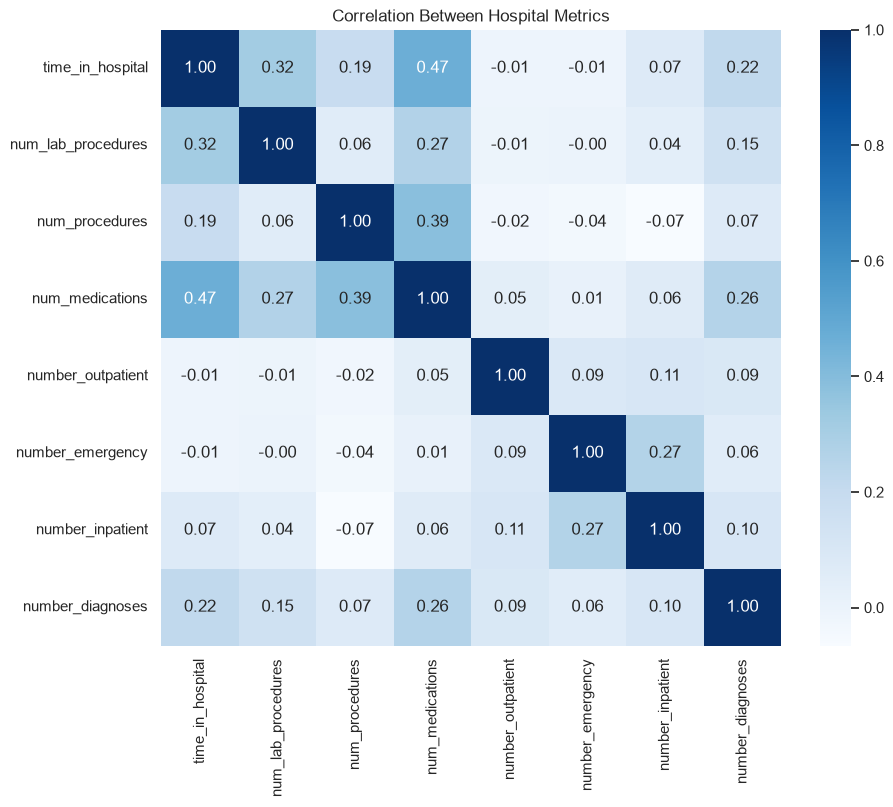

In [32]:
# ==========================================================
# Correlation Analysis
# ==========================================================

# Select numerical columns for analysis
corr_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Compute correlation matrix
correlation_matrix = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Hospital Metrics")

plt.show()

### Key Findings

- Most numerical variables showed weak to moderate correlations.
- Patients with more diagnoses generally received more medications and laboratory procedures.
- No single variable strongly explained hospital utilization, suggesting that patient care depends on multiple factors.

---

### Business Insight

Hospital operations are influenced by multiple patient and treatment characteristics rather than a single metric. Considering several indicators together provides a more comprehensive understanding of patient care and hospital performance.

---
---

# Executive Summary

This project analyzed **101,766** hospital admissions across **71,518** unique diabetic patients to evaluate readmission patterns, demographic trends, hospital utilization, and clinical treatment practices.

The analysis showed that **53.9%** of patients were not readmitted, while **35.5%** returned after 30 days and **11.1%** were readmitted within 30 days.

The patient population primarily consisted of older adults, with the **70–80 years** age group representing the largest proportion of admissions. Female patients accounted for a slightly higher share of hospitalizations than males.

Hospital utilization analysis indicated that most patients experienced relatively short hospital stays while receiving multiple laboratory procedures, medications, and diagnoses during treatment.

Admission analysis showed that emergency admissions and physician referrals represented major entry pathways into the hospital. In addition, most patients received diabetes medication during hospitalization, although medication adjustments occurred for a smaller proportion of patients.

Correlation analysis identified generally weak to moderate relationships among hospital metrics, suggesting that patient care and hospital utilization are influenced by multiple factors rather than a single characteristic.

Overall, the analysis provides a comprehensive overview of hospital operations and patient care patterns, offering valuable insights that can support healthcare planning and operational decision-making.

---
---

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Strengthen follow-up care for patients at higher risk of readmission, particularly during the first 30 days after discharge.

2. Continue focusing preventive care initiatives on older adults, who represent the largest group of hospitalized patients.

3. Monitor hospital resource utilization by tracking hospital stay duration, laboratory procedures, and medication usage to improve operational efficiency.

4. Review medication management practices to better understand cases requiring treatment adjustments during hospitalization.

5. Develop interactive dashboards that allow hospital administrators to monitor admissions, treatment patterns, and readmission trends in real time.

6. Perform regular data quality assessments to ensure accurate reporting and reliable decision-making.

---
---

# Conclusion

This project demonstrates a complete Data Analyst workflow, including data cleaning, exploratory data analysis, visualization, and business reporting.

The analysis provided meaningful insights into patient demographics, hospital utilization, treatment practices, and readmission patterns using more than 100,000 hospital admission records.

The findings can support hospital administrators in understanding patient care trends, improving operational planning, and identifying opportunities to enhance healthcare services.

This project also highlights practical skills in Python, Pandas, NumPy, Matplotlib, Seaborn, and business-oriented data storytelling, making it a strong portfolio project for an entry-level Data Analyst role.

---
---                                                                                                                                                                          